# Interpretabilidad

Recuerada que existen modelos de caja blanca, como los árboles de decisión, que no tienen un problema de interpretabilidad. Sin embargo, este hecho es excepcional: la mayoría de modelos, más aún dentro del campo del _deep learning_, son de caja negra. Es decir: se conoce la información de entrada y el resultado, pero no existe una forma trivial de enlazar ambos datos.

La **intepretabilidad** es una rama dentro del _machine learning_ que tiene como objetivo explicar las decisiones tomadas por estos modelos. Es un campo general dentro de la Inteligencia Artificial (no está directamente vinculada con el _deep learning_), así que tiene estrategias para explicar modelos de caja negra clásicos y otras para explicar modelos de caja negra _deep_.

Durante este cuadernillo daremos cobertura a ambos contextos: clásico y _deep_.

## Interpretabilidad de modelos _deep_ (técnica Grad-CAM)

Aprovechando que el tema actual trata los modelos _deep_, hablaremos primero de la interpretabilidad de este tipo de modelos.

La técnica principal, denominada Grad-CAM y definida en [este trabajo](https://arxiv.org/abs/1611.07450), es introducir una capa extra en la parte final de los modelos (la que determina el resultado --etiqueta, imagen...--) que sea capaz de explicar los cambios en el gradiente que allí se producen.

Veamos un ejemplo. Lo primero que vamos a hacer es recuperar el modelo de clasificación de imágenes que creamos en el cuadernillo ```502```.

Instalamos e importamos las librerías necesarias.

In [ ]:
!pip install fastai -Uqqq
!pip install fastprogress==1.0.3 # 08/02/2026: esta librería se ha actualizado. Hasta que FASTAI se actualice, tenemos que usar la versión anterior

  Attempting uninstall: fastprogress
  Attempting uninstall: fastprogress
    Found existing installation: fastprogress 1.1.3
    Uninstalling fastprogress-1.1.3:
      Successfully uninstalled fastprogress-1.1.3
    Found existing installation: fastprogress 1.1.3
    Uninstalling fastprogress-1.1.3:
      Successfully uninstalled fastprogress-1.1.3


In [ ]:
from fastai.vision.all import *

random_seed = 33

Recuperamos nuestros datos desde [este enlace](https://cipfpd-my.sharepoint.com/:f:/g/personal/rescobedo_fpdrioja_es/EgmzwXhOQOBPsG7oktQ4uCMBNGi8gr6kEFHl1W0MiFPoRQ) y los estructuramos.

In [ ]:
%%capture
!unzip 502\ cat_dog_dataset.zip

In [ ]:
dataset_path = Path("dataset")
test_path = Path(dataset_path/"test")
train_path = Path(dataset_path/"train")

Definimos las transformaciones que necesitamos para realizar aumento de datos.

In [ ]:
from albumentations import *

class TransformPipeline(ItemTransform):
  def __init__(self, train = True):
    if train:
      self.aug = Compose([
        VerticalFlip(p = 0.2),
        GaussNoise(p = 0.2),
        Rotate(p = 0.2),
        Resize(256, 256, p = 1) # esto se aplica siempre
      ])
    else:
      self.aug = Compose([
        Resize(256, 256, p = 1) # en testeo, solo aplico el cambio de tamaño
      ])

  def encodes(self, x): # este método es muy importante, recibe cada uno de los datos y lo procesa
    if len(x) == 1:
      return x

    image, label = x
    res = self.aug(image = np.array(image)) # nuestro procesamiento es aplicar aumentos a la imagen
    return PILImage.create(res["image"]), label

Creamos un ```DataBlock``` y obtenemos su ```DataLoader``` asociado.

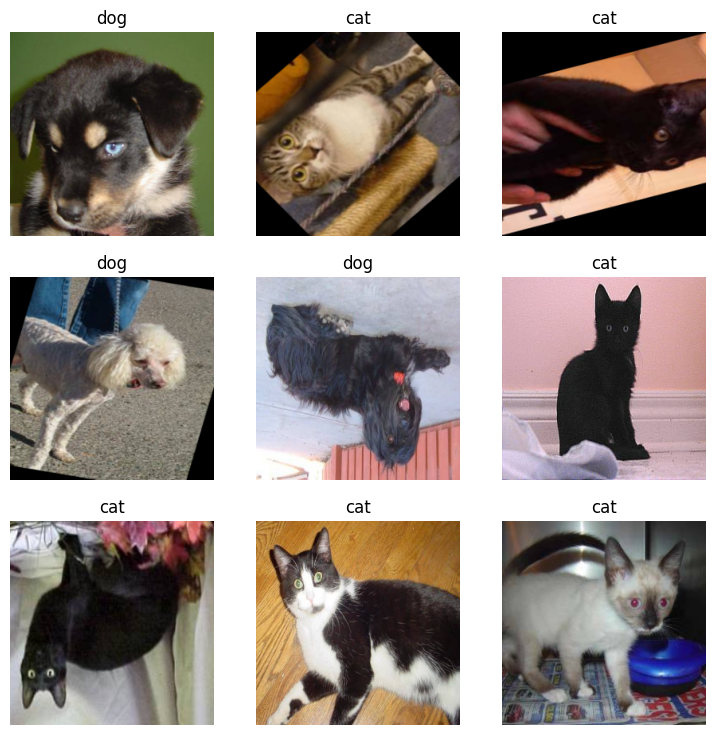

In [ ]:
db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct = 0.2, seed = random_seed),
    get_y = parent_label,
    item_tfms = [TransformPipeline(train = True)]
)

dls = db.dataloaders(train_path)

dls.show_batch()

Ahora el ```Learner```.

In [ ]:
learner = vision_learner(dls, resnet50)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 54.7MB/s]


SuggestedLRs(valley=0.0005754399462603033)

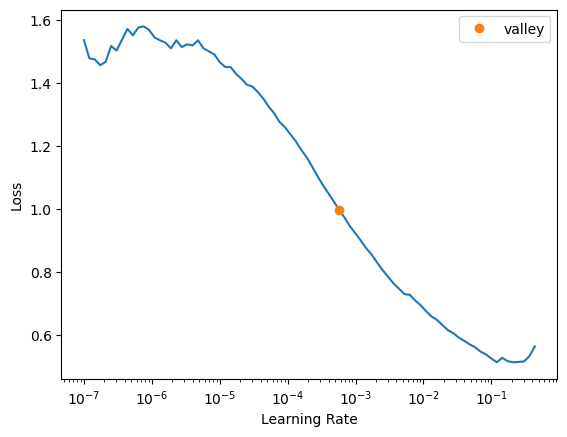

In [ ]:
learner.lr_find()

Entrenamos.

In [ ]:
learner.fine_tune(10, 0.001, 2)

epoch,train_loss,valid_loss,time
0,1.336133,0.807962,00:02
1,1.133200,0.211048,00:02


epoch,train_loss,valid_loss,time
0,0.347549,0.183712,00:03
1,0.316869,0.145966,00:02
2,0.307043,0.127591,00:02
3,0.252488,0.170241,00:02
4,0.217117,0.223533,00:02
5,0.205050,0.207772,00:02
6,0.185867,0.190592,00:02
7,0.174461,0.171113,00:02
8,0.159181,0.160037,00:02
9,0.150568,0.155115,00:02


Ahora que el modelo está entrenado, podemos introducir la capa extra de **interpretabilidad**.

Usaremos el mapa de activación de clases (CAM) que utiliza la última capa y los resultados del propio modelo para mostrar un mapa de calor.

En particular, usaremos los gradientes de estas capas. No podemos acceder a ellos directamente, sino que necesitamos utilizar un ```hook```. Los ```hook``` son parecidos a los ```CallBacks```. Mientras que estos segundos nos permitían añadir código antes o después de las etapas de creación, entrenamiento y testeo del modelo, los ```hook``` nos permiten añadir código en las etapas de propagación de los gradientes (_forward_ y _backforward_).

In [ ]:
class Hook():
  def __init__(self, model):
    self.hook = model.register_forward_hook(self.hook_func)

  def hook_func(self, model, input, output):
    self.stored = output.detach().clone()

  def __enter__(self, *args):
    return self

  def __exit__(self, *args):
    self.hook.remove()

In [ ]:
class HookBwd():
  def __init__(self, model):
    self.hook = model.register_backward_hook(self.hook_func)

  def hook_func(self, model, grid_input, grid_output):
    self.stored = grid_output[0].detach().clone()

  def __enter__(self, *args):
    return self

  def __exit__(self, *args):
    self.hook.remove()

Ahora vamos a crear el ```DataLoader``` de testeo.

In [ ]:
db_test = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = GrandparentSplitter(train_name = "train", valid_name = "test"),
    get_y = parent_label,
    item_tfms = [TransformPipeline(train = False)]
)

dls_test = db.dataloaders(dataset_path)
learner.dls = dls_test

Y ahora podemos predecir un ejemplo cualquiera.

In [ ]:
example = test_path/"cat/cat.4896.jpg"
img = PILImage.create(example)
example_coded = first(dls_test.test_dl([img]))[0]
print(learner.predict(img))

('cat', tensor(0), tensor([0.8595, 0.1405]))


Bien, está bien predicho con una certeza del 98% (al menos el modelo está al 98% seguro de que es un gato).

La pregunta importante ahora es, **_¿por qué el modelo está tan seguro de que es un gato?_** **_¿En qué se está fijando?_**.

Aplicando técnicas de **interpretabilidad** sobre el objeto x podremos descubrirlo.

Usando los ```hook``` que hemos definido antes, vamos a capturar los descriptores de la última capa convolucional y vamos a calcular los gradientes de las activaciones para la clase _gato_ (_cat_).

In [ ]:
with HookBwd(learner.model[0]) as hookg:
  with Hook(learner.model[0]) as hook:
    output = learner.model.eval()(example_coded.cuda())
    act = hook.stored
  output[0, 0].backward()
  grad = hookg.stored

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Necesitamos la media de los pesos de los gradientes. Podemos obtenerla de la siguiente forma:

In [ ]:
w = grad[0].mean(dim = [1, 2], keepdim = True)
cam_map = (w * act[0]).sum(0)

Finalmente, creamos un mapa de calor y lo visualizamos.

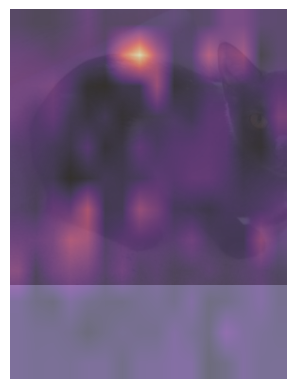

In [ ]:
# decodificamos la imagen ejemplo
example_decoded = TensorImage(dls.train.decode((example_coded,))[0][0])

# visualización
_, ax = plt.subplots()
example_decoded.show(ctx = ax)
ax.imshow(
  cam_map.detach().cpu(),
  alpha = 0.6,
  extent = (0, example_coded.shape[2], example_coded.shape[3], 0),
  interpolation='bilinear',
  cmap='magma'
);

Como puedes observar, el modelo determina que esa imagen es un gato por los puntos más brillantes:
- Lomo.
- Patas traseras.
- Orejas.

Esta técnica de **interpretabilidad** puede aplicarse a cualquier capa del modelo, aunque la más interesante es la última (que es donde se determina la clase final).

## Interpretabilidad de modelos clásicos (técnica ```model distillation```)

En los modelos clásicos, una de las formas más comunes de explicar modelos de caja negra es usando modelos de caja blanca.

La idea es sencilla: como existen modelos que, de por sí, son interpretables; podemos utilizar estos modelos para explicar otros que no lo sean. El proceso es el siguiente:
- Se entrena el modelo de **caja negra**.
- Se predicen los resultados.
- Se entrena el modelo de **caja blanca** mimetizando el comportamiento del modelo de **caja negra**, es decir: el resultado esperado para el modelo de **caja blanca** es el resultado predicho por el modelo de **caja negra**.
- Se interpretan los resultados de la predicción del modelo de **caja blanca**.

Esta técnica es interesante porque puede aplicarse a más campos además del de la **interpretabilidad**. Por ejemplo, nos permite crear _pseudoetiquetadores_ para realizar tareas de aprendizaje semi-supervisado con modelos _deep_.

Veamos un ejemplo.

### Entrenamiento del modelo de caja negra

#### Los datos

Lo primero que vamos a hacer es entrenar un modelo clásico, tal y como lo hacíamos en el tema 4. Por ejemplo, entrenaremos un ```RandomForest``` (que, como ya sabes, aunque sea la unión de varios modelos de caja blanca, es de caja negra).

Vamos a recuperar el mismo ejemplo del cuadernillo ```309```, que clasificábamos fumadores. Recupera el [conjunto de datos](https://www.kaggle.com/competitions/playground-series-s3e24/data) que usábamos.

In [ ]:
%%capture
!unzip playground-series-s3e24.zip

In [ ]:
import pandas as pd

In [ ]:
train_val = pd.read_csv("train.csv")
train_val.head()

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,0,55,165,60,81.0,0.5,0.6,1,1,135,...,40,75,16.5,1,1.0,22,25,27,0,1
1,1,70,165,65,89.0,0.6,0.7,2,2,146,...,57,126,16.2,1,1.1,27,23,37,1,0
2,2,20,170,75,81.0,0.4,0.5,1,1,118,...,45,93,17.4,1,0.8,27,31,53,0,1
3,3,35,180,95,105.0,1.5,1.2,1,1,131,...,38,102,15.9,1,1.0,20,27,30,1,0
4,4,30,165,60,80.5,1.5,1.0,1,1,121,...,44,93,15.4,1,0.8,19,13,17,0,1


Aunque ahora no vayamos a hacer inferencia, siempre es buena costumbre separar el conjunto de testeo.

In [ ]:
from sklearn.model_selection import train_test_split

random_seed = 33

In [ ]:
train, val = train_test_split(train_val, test_size=0.15, random_state=random_seed)

#### Limpieza de datos

Columnas inútiles. Tenemos una columna id que no necesitamos para nada en el entrenamiento.

In [ ]:
train = train.drop(columns = "id")
val = val.drop(columns = "id")

Datos sin sentido. Son datos médicos, así que no controlo qué datos pueden tener o no sentido (más allá de los evidentes, como ```age```).

In [ ]:
train.describe()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000,...,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000,135367.000000
mean,44.297214,165.267200,67.152105,83.004576,1.005707,1.001044,1.024097,1.023529,122.511491,76.882401,...,55.851241,114.589176,14.796780,1.074331,0.892941,25.522661,26.570013,36.294769,0.197929,0.437285
std,11.840802,8.816742,12.594423,8.968346,0.399835,0.391239,0.153352,0.151576,12.731839,8.992300,...,13.961877,28.374666,1.431559,0.348729,0.179545,9.560375,18.185182,31.319507,0.398440,0.496053
min,20.000000,135.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,77.000000,44.000000,...,9.000000,1.000000,4.900000,1.000000,0.100000,6.000000,3.000000,2.000000,0.000000,0.000000
25%,40.000000,160.000000,60.000000,77.000000,0.800000,0.800000,1.000000,1.000000,114.000000,70.000000,...,45.000000,95.000000,13.800000,1.000000,0.800000,20.000000,16.000000,18.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,83.000000,1.000000,1.000000,1.000000,1.000000,121.000000,78.000000,...,54.000000,114.000000,15.000000,1.000000,0.900000,24.000000,22.000000,27.000000,0.000000,0.000000
75%,55.000000,170.000000,75.000000,89.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,...,64.000000,133.000000,15.800000,1.000000,1.000000,29.000000,32.000000,44.000000,0.000000,1.000000
max,85.000000,190.000000,130.000000,127.000000,9.900000,9.900000,2.000000,2.000000,213.000000,133.000000,...,136.000000,1860.000000,21.000000,6.000000,9.900000,778.000000,2914.000000,926.000000,1.000000,1.000000


Valores atípicos. Vamos a ver si tenemos alguno.

In [ ]:
def outlier_eliminator(df, threshold: float = 0.05):
  s_df = df.describe() # statistical dataframe

  for column in s_df.columns:
    # datos necesarios
    n = s_df.loc["count", column]
    q1 = s_df.loc["25%", column]
    q3 = s_df.loc["75%", column]
    mean = s_df.loc["mean", column] # 50% no es la media, es la mediana
    iqr = (q3 - q1) * 1.5

    # calculos
    _range = [mean - iqr, mean + iqr]
    outliers = df[(df[column] < _range[0]) | (df[column] > _range[1])]

    # outliers
    print(f"Outliers para la columna {column}: {len(outliers)} de {n}. BORRADOS: ", end="")
    if len(outliers) != 0 and len(outliers) / n < threshold:
      print("Sí.")
      df = df[(df[column] > _range[0]) & (df[column] < _range[1])] # fíjate que le doy la vuelta
    else:
      print("No.")

    print("### --- ###")

  return df

In [ ]:
train = outlier_eliminator(train, threshold = 0.025)

Outliers para la columna age: 7225 de 135367.0. BORRADOS: No.
### --- ###
Outliers para la columna height(cm): 13873 de 135367.0. BORRADOS: No.
### --- ###
Outliers para la columna weight(kg): 8932 de 135367.0. BORRADOS: No.
### --- ###
Outliers para la columna waist(cm): 5750 de 135367.0. BORRADOS: No.
### --- ###
Outliers para la columna eyesight(left): 6711 de 135367.0. BORRADOS: No.
### --- ###
Outliers para la columna eyesight(right): 6987 de 135367.0. BORRADOS: No.
### --- ###
Outliers para la columna hearing(left): 135367 de 135367.0. BORRADOS: No.
### --- ###
Outliers para la columna hearing(right): 135367 de 135367.0. BORRADOS: No.
### --- ###
Outliers para la columna systolic: 7439 de 135367.0. BORRADOS: No.
### --- ###
Outliers para la columna relaxation: 5392 de 135367.0. BORRADOS: No.
### --- ###
Outliers para la columna fasting blood sugar: 13765 de 135367.0. BORRADOS: No.
### --- ###
Outliers para la columna Cholesterol: 2580 de 135367.0. BORRADOS: Sí.
### --- ###
Outlie

Estadísticos básicos. Vamos a ver si existen nulos.

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131381 entries, 149220 to 154644
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  131381 non-null  int64  
 1   height(cm)           131381 non-null  int64  
 2   weight(kg)           131381 non-null  int64  
 3   waist(cm)            131381 non-null  float64
 4   eyesight(left)       131381 non-null  float64
 5   eyesight(right)      131381 non-null  float64
 6   hearing(left)        131381 non-null  int64  
 7   hearing(right)       131381 non-null  int64  
 8   systolic             131381 non-null  int64  
 9   relaxation           131381 non-null  int64  
 10  fasting blood sugar  131381 non-null  int64  
 11  Cholesterol          131381 non-null  int64  
 12  triglyceride         131381 non-null  int64  
 13  HDL                  131381 non-null  int64  
 14  LDL                  131381 non-null  int64  
 15  hemoglobin       

Parece que no vamos a tener que preocuparnos de esto.

Correlación. ¿Habrá columnas correladas?

In [ ]:
corr = train.corr()
for column in corr:
  for index in corr.index:
    corr_v = abs(corr.loc[index, column])
    if corr_v > 0.8 and not corr_v == 1.0:
      print(f"Valor correlado en {index} - {column}, valor: {corr.loc[index, column]}")

Valor correlado en waist(cm) - weight(kg), valor: 0.8318937180691987
Valor correlado en weight(kg) - waist(cm), valor: 0.8318937180691987
Valor correlado en LDL - Cholesterol, valor: 0.8615422439306766
Valor correlado en Cholesterol - LDL, valor: 0.8615422439306766


Eliminamos una de las parejas correladas.

In [ ]:
train = train.drop(columns = ["waist(cm)", "Cholesterol"])
val = val.drop(columns = ["waist(cm)", "Cholesterol"])
train_val = train_val.drop(columns = ["waist(cm)", "Cholesterol"])

Variabilidad. Veamos si tenemos problemas de variabilidad.

In [ ]:
def numerical_variability(df, threshold: float = 0.1):
  numerical_df = df.select_dtypes("number")

  for column in numerical_df.columns:
    serie = numerical_df[column].value_counts()
    _max = serie.iloc[0] # primer elemento (el más grande) ; max es una palabra reservada
    prop = _max / len(df) * 100.0 # proportion
    if prop > threshold * 100.0:
      print(f"Cuidado, la proporción de valores idénticos para la columna {column} es de {prop}%, que supera el threshold establecido.")

In [ ]:
numerical_variability(train)

Cuidado, la proporción de valores idénticos para la columna age es de 29.582664159962246%, que supera el threshold establecido.
Cuidado, la proporción de valores idénticos para la columna height(cm) es de 23.629748593784488%, que supera el threshold establecido.
Cuidado, la proporción de valores idénticos para la columna weight(kg) es de 15.216812172231906%, que supera el threshold establecido.
Cuidado, la proporción de valores idénticos para la columna eyesight(left) es de 23.52471057458841%, que supera el threshold establecido.
Cuidado, la proporción de valores idénticos para la columna eyesight(right) es de 23.98596448497119%, que supera el threshold establecido.
Cuidado, la proporción de valores idénticos para la columna hearing(left) es de 97.61304907102244%, que supera el threshold establecido.
Cuidado, la proporción de valores idénticos para la columna hearing(right) es de 97.66480693555386%, que supera el threshold establecido.
Cuidado, la proporción de valores idénticos para l

Eliminamos columnas con poca variabilidad.

In [ ]:
train = train.drop(columns=["hearing(left)", "hearing(right)", "Urine protein"])
val = val.drop(columns=["hearing(left)", "hearing(right)", "Urine protein"])
train_val = train_val.drop(columns=["hearing(left)", "hearing(right)", "Urine protein"])

**NO** voy a estandarizar, porque si lo hago no podré interpretar mis resultados.

Separo los datos en características y etiquetas.

In [ ]:
X_train, y_train = train.drop(columns = "smoking"), train.smoking
X_val, y_val = val.drop(columns = "smoking"), val.smoking
X_train_val, y_train_val = train_val.drop(columns = "smoking"), train_val.smoking

#### Entrenamiento

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay

Definimos la función para predecir (hacerlo de forma más sencilla).

In [ ]:
def evaluate(X_train, y_train, X_test, y_test, model):
  model = model.fit(X_train, y_train)

  # train
  train_pred = model.predict(X_train)
  train_score = roc_auc_score(y_train, train_pred)

  # test
  test_pred = model.predict(X_test)
  test_score = roc_auc_score(y_test, test_pred)

  return model, train_score, test_score, train_pred, test_pred

### Predicción de los resultados

Predecimos.

In [ ]:
model = RandomForestClassifier(random_state=random_seed)
model, train_score, test_score, train_pred, val_pred = evaluate(X_train, y_train, X_val, y_val, model)

Aquí tenemos la curva ROC del modelo.

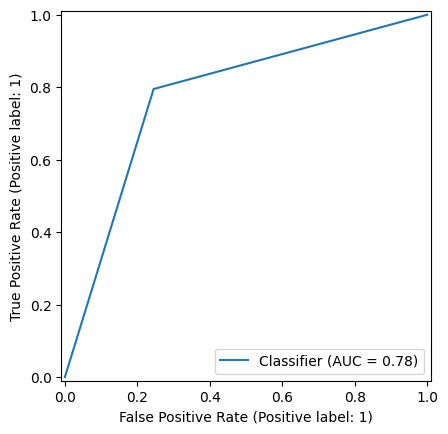

In [ ]:
RocCurveDisplay.from_predictions(y_val, val_pred);

(No vamos a meternos a optimizar el modelo).

### Entrenamiento del modelo de caja blanca

Ahora, realizamos la técnica de ```model distillation```: entrenamos un modelo de caja blanca con los resultados del modelo de caja negra.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

interp = DecisionTreeClassifier(max_depth = 3, random_state = random_seed)

Fíjate cómo se usan los mismos datos de entreda, pero las predicciones del modelo de caja negra (estamos usando su conocimiento).

In [ ]:
interp = interp.fit(X_train, train_pred)

### Interpretación

Para realizar la interpretación, podemos usar la función ```plot_tree```.

In [ ]:
train

,age,height(cm),weight(kg),eyesight(left),eyesight(right),systolic,relaxation,fasting blood sugar,triglyceride,HDL,LDL,hemoglobin,serum creatinine,AST,ALT,Gtp,dental caries,smoking
149220,60,170,80,0.9,0.7,124,83,127,102,72,119,15.5,1.0,23,19,25,0,0
81952,75,140,50,0.5,0.7,145,67,120,199,42,107,13.1,0.6,20,16,18,0,0
39080,45,170,70,1.0,1.2,138,88,85,145,35,124,15.8,1.0,19,19,22,1,0
144444,50,165,70,1.0,1.2,132,94,97,257,48,120,14.8,1.0,30,43,69,1,1
32600,50,155,65,0.9,1.0,100,60,150,271,48,78,11.7,0.8,41,63,55,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75971,40,160,65,1.2,1.2,138,80,89,92,89,99,13.5,0.6,21,18,15,0,0
158921,50,170,60,0.3,0.4,125,80,99,211,61,84,16.2,0.9,15,12,37,1,1
131650,30,180,105,0.9,0.7,126,84,78,85,38,137,15.5,0.8,29,46,50,1,1
104152,35,170,70,1.5,1.5,130,85,92,73,49,115,15.6,1.0,36,37,15,0,0


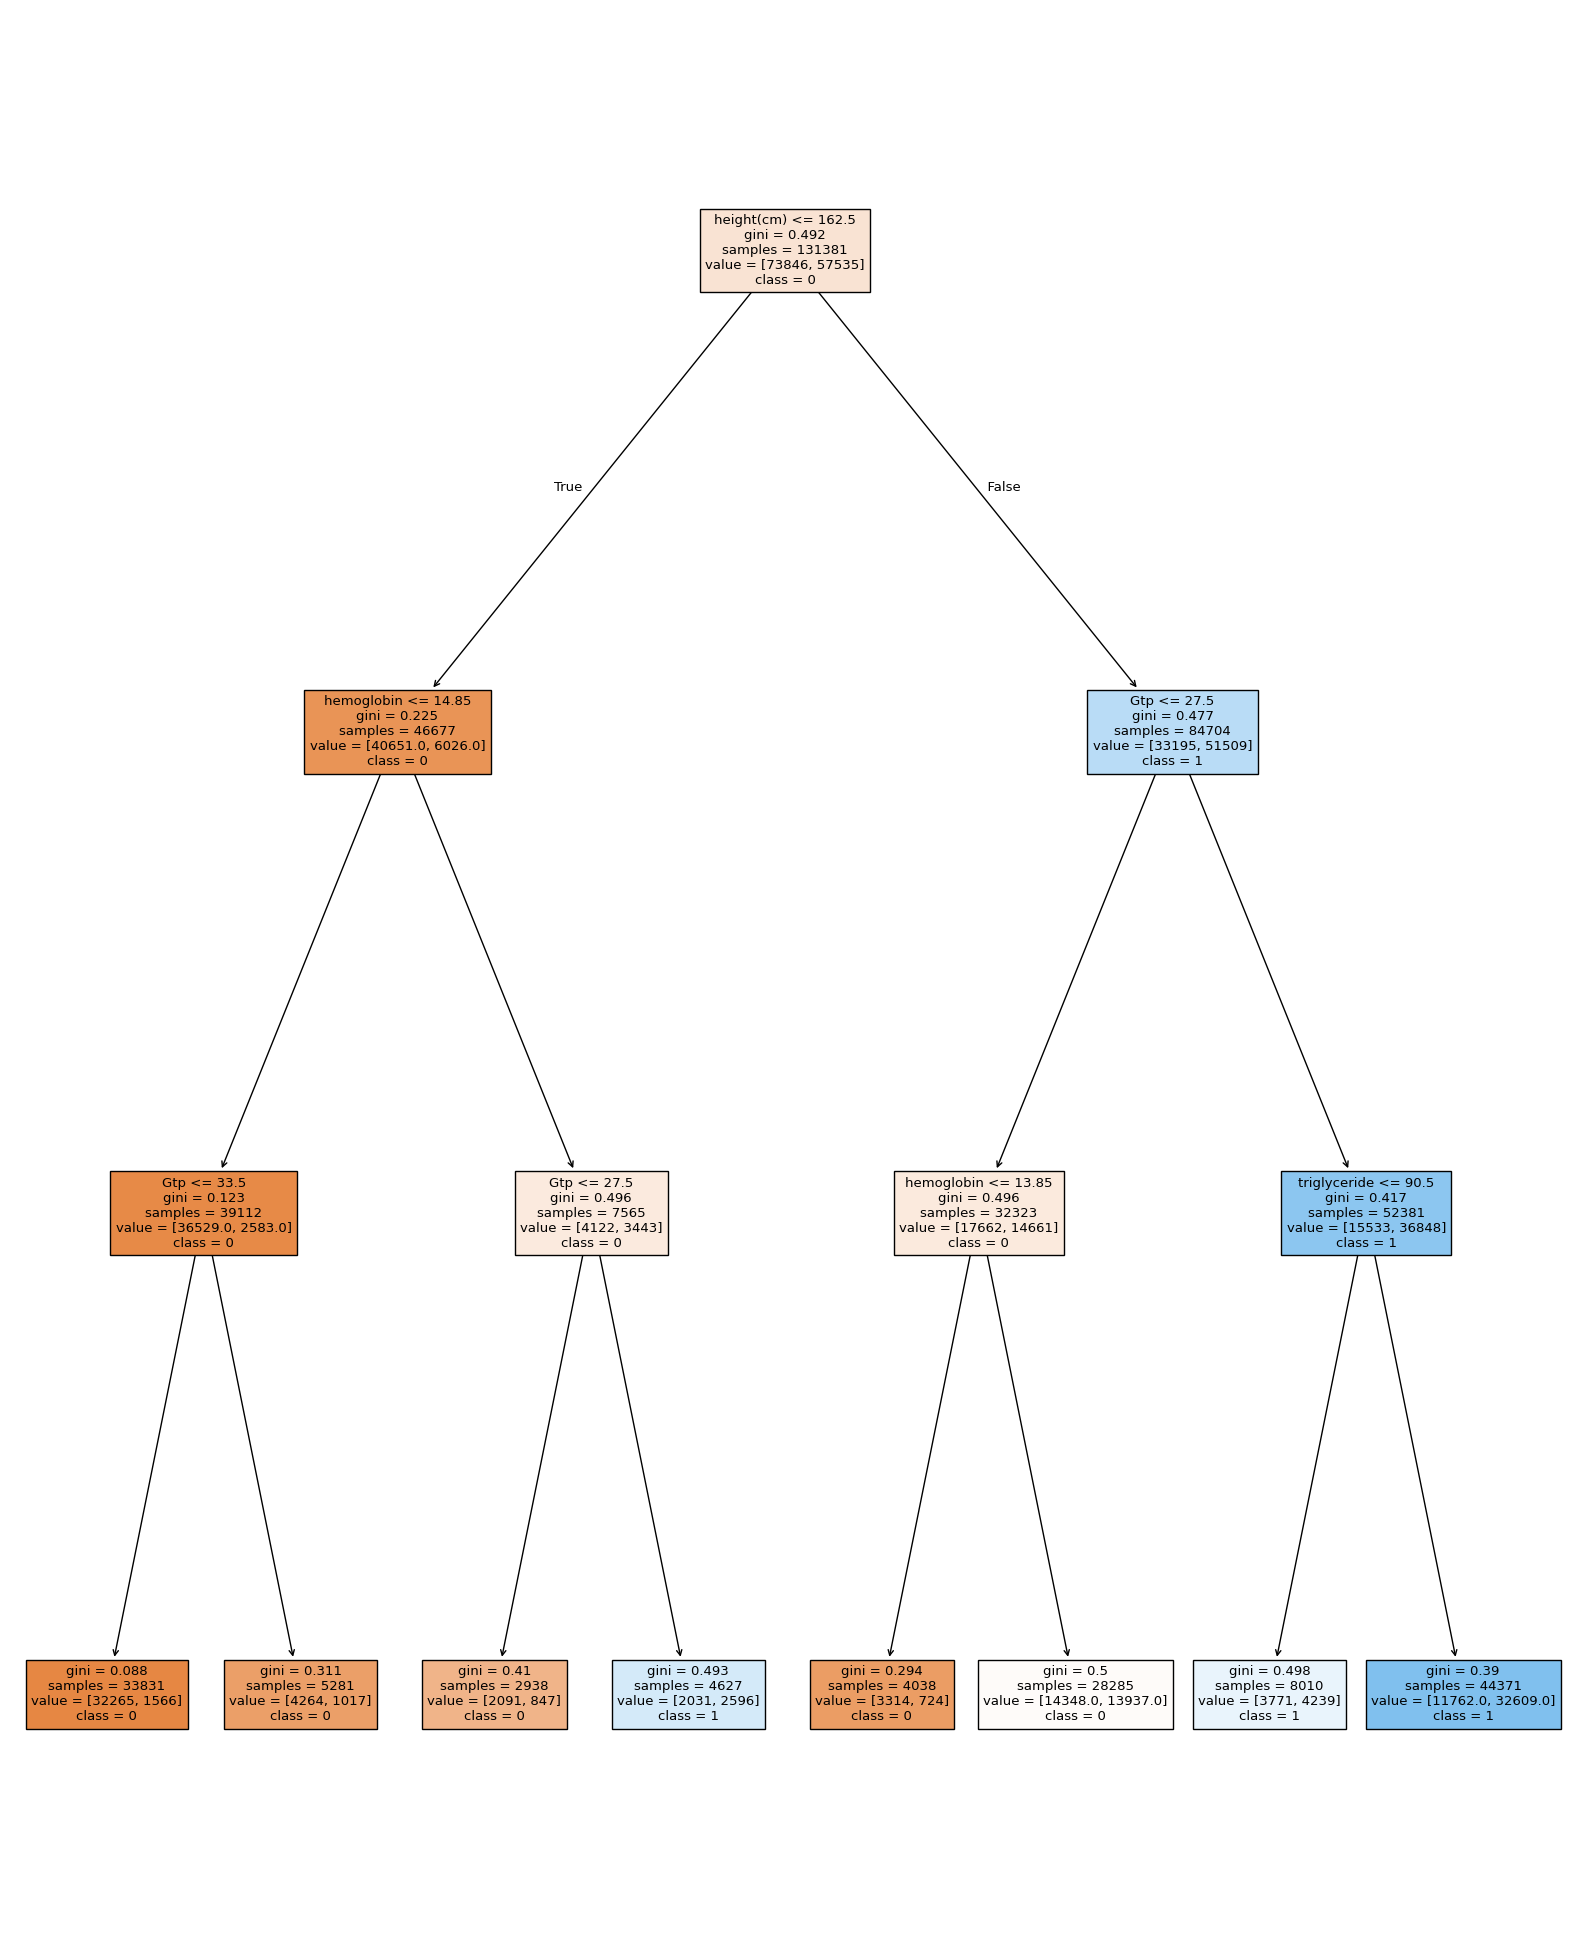

In [ ]:
from sklearn.tree import plot_tree

fig = plt.figure(figsize = (20, 25)) # puedes modificar esto según el tamaño del árbol
plot_tree(interp, feature_names = X_train.columns, class_names = y_train.unique().astype(str), filled = True);

Como se puede ver en el gráfico, la variable más importante es la altura, siendo la hemogrobina y ```gtp``` dos variables también muy importantes.

De hecho, como se conocen las reglas lógicas, se puede determinar que a esta persona le dará (o no) un infarto porque una determinada variable está por encima de un rango específico (que es justo lo que se hace en los análisis).

### ¿Por qué no usar directamente el clasificador de caja blanca?

Esta pregunta te la tienes que hacer siempre que vayas a realizar interpretabilidad sobre un modelo: **quizá el modelo interpretable es suficiente para dar solución al problema**.

Podemos comprobarlo.

In [ ]:
other_model = DecisionTreeClassifier(random_state = random_seed)
other_model, train_score, test_score, train_pred, val_pred = evaluate(X_train, y_train, X_val, y_val, other_model)

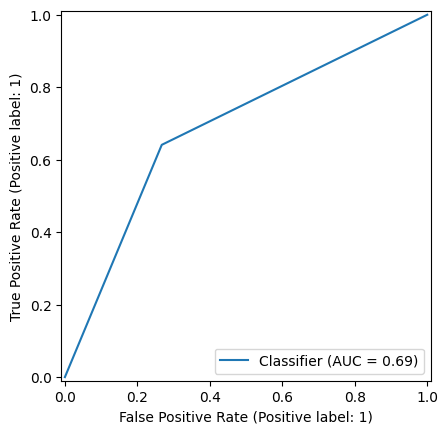

In [ ]:
RocCurveDisplay.from_predictions(y_val, val_pred);

En este caso, es más útil el modelo de caja negra (**0.78** frente a **0.69**), por lo que será más práctico entrenar y usar el modelo de caja negra y, **cuando sea necesario**, explicar los resultados con el modelo de caja blanca.

# Resumen

Los modelos de caja negra y arquitecturas _deep_ suelen tener unos resultados excepcionales en comparación con los de caja blanca. Sin embargo, tienen la gran limitación de no poder ser explicados.

En muchos contextos, la explicabilidad (interpretabilidad) es un requisito obligatorio, pues puede haber personas involucradas y hay que dar una explicación de por qué se ha tomado esa decisión:
- Contextos médicos (detección de enfermedades, simulación de operaciones...)
- Contextos agrícolas (fumigación, riego...)
- Contextos policiales (análisis forense, identificación de patrones...)
- Contextos bancarios (asignación de préstamos, desahucios...)

En todos estos casos, en general, se intentará usar un modelo de caja negra (mejores resultados), pero también se usará un modelo de caja blanca para explicarlos: de esta forma, se conservan los resultados superiores, pero además se crea la capa explicable necesaria.